In [1]:
# Set CUDA device before importing torch to avoid device conflicts
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from tqdm.auto import tqdm

import models

In [2]:
%config InlineBackend.figure_format = 'retina'
DATA_DIRECTORY = Path("/gpfs/users/leliorzou/earth_data_science/2-volcano-seismology/NVCHVC")
FILES = list(DATA_DIRECTORY.glob("**/*.npy"))
LABELS = {1: "VT", 2: "LP", 3: "TR", 4: "AV", 5: "IC"}

Data shape: 14 channels x 8192 samples


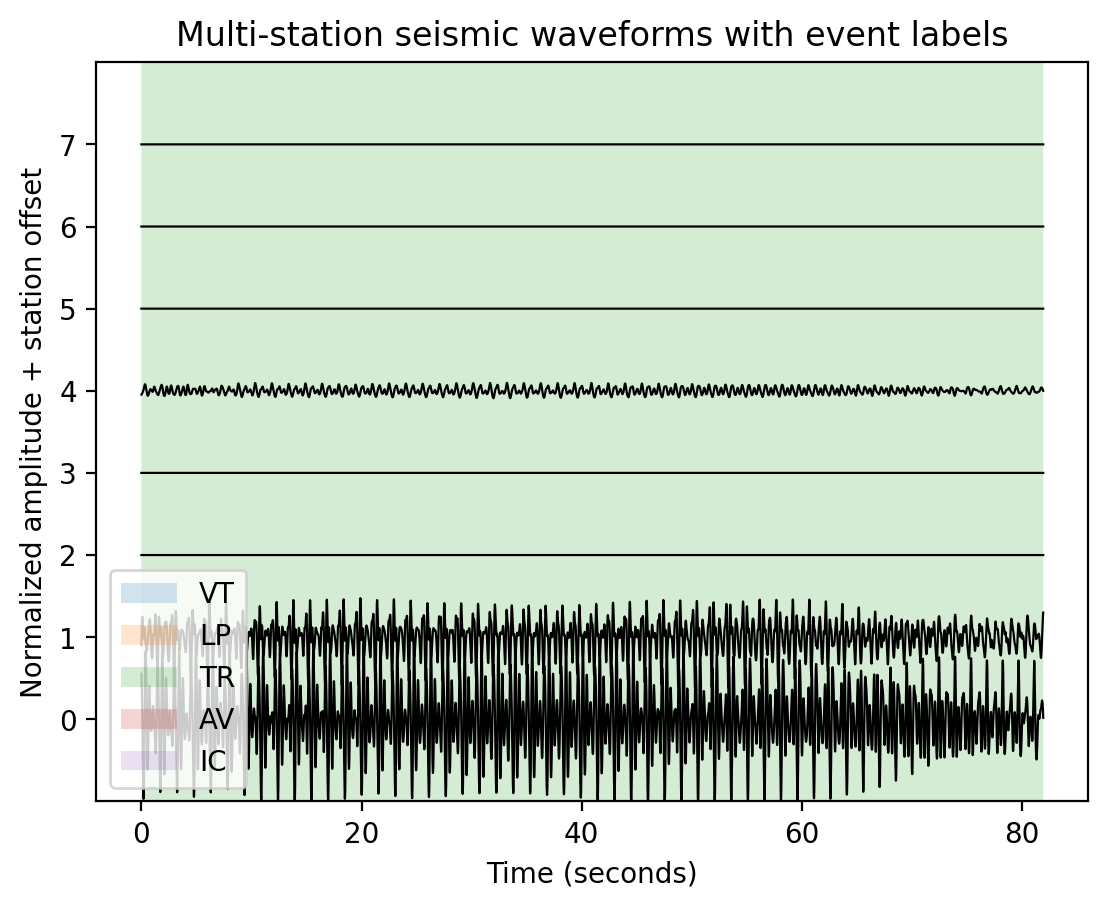

In [3]:
# Randomly select a file
filepath = np.random.choice(FILES)

# Load and inspect the data
sampling_rate = 100
n_stations = 8
data = np.load(filepath)
waveforms = data[:n_stations]
labels = data[n_stations + 1 :]
print(f"Data shape: {data.shape[0]} channels x {data.shape[1]} samples")

# Plot waveforms
fig, ax = plt.subplots(sharex=True)
time = np.arange(data.shape[1]) / sampling_rate
ax.plot(time, waveforms.T + np.arange(8)[None, :], c="k", lw=0.8)

# Label regions
for c, label in enumerate(LABELS.values()):
    ax.fill_between(time, -1, n_stations, labels[c], alpha=0.2, label=label)

# Axes cosmetics
ax.legend()
ax.set(
    xlabel="Time (seconds)",
    ylabel="Normalized amplitude + station offset",
    title="Multi-station seismic waveforms with event labels",
    ylim=(-1, 8),
    yticks=np.arange(8),
)
plt.show()

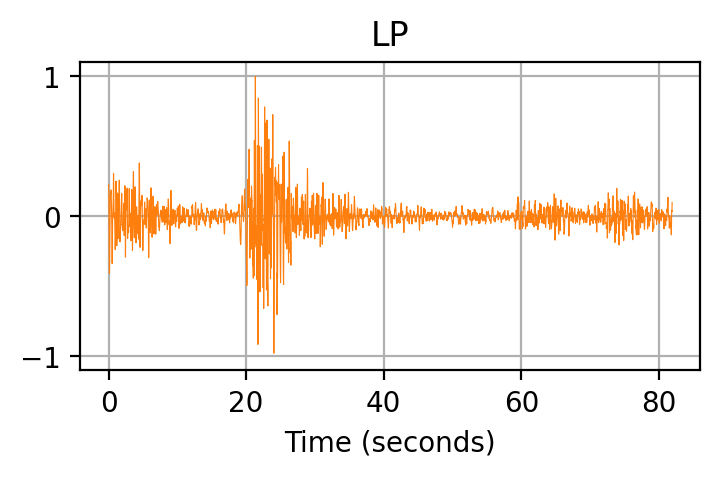

In [4]:
def load_event(filepath, n_stations=8) -> dict:
    """Load a seismic event file and extract the best waveform.

    Parameters
    ----------
    filepath : str or Path
        Path to the .npy file containing seismic event data.
    n_stations : int
        Number of seismic stations (default is 8).

    Returns
    -------
    dict
        A dictionary with keys 'waveform' and 'label'.
    """
    data = np.load(filepath)
    waveforms = data[:n_stations]
    labels = data[n_stations + 1 :]
    amplitudes = np.max(np.abs(waveforms), axis=1)
    best_station = np.argmax(amplitudes)
    waveform = waveforms[best_station] / np.max(
        np.abs(waveforms[best_station])
    )
    label = LABELS[np.argmax(np.sum(labels, axis=1)) + 1]
    return {"waveform": waveform, "label": label}


def get_color(label):
    """Get a color for a given label."""
    return f"C{list(LABELS.values()).index(label)}"


def plot_event(event, ax=None, show=True, **kwargs):
    """Plot the waveform from the event dictionary."""
    kwargs.setdefault("color", get_color(event["label"]))
    kwargs.setdefault("lw", 0.4)
    waveform = event["waveform"]
    label = event["label"]
    time = np.arange(len(waveform)) / sampling_rate
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 2))
    ax.plot(time, waveform, **kwargs)
    ax.set(
        title=label,
        xlabel="Time (seconds)",
        ylim=[-1.1, 1.1],
        yticks=[-1, 0, 1],
    )
    ax.grid()
    if show:
        plt.show()


# Test the function
event = load_event(np.random.choice(FILES))
plot_event(event)

In [5]:
def collect_balanced_data(dirpath, n_per_class=20):
    """Collect balanced samples from each event type."""
    np.random.seed(42)
    events = []
    for event_dir in dirpath.iterdir():
        if event_dir.is_dir():
            files = list(event_dir.glob("*.npy"))
            n_sample = min(n_per_class, len(files))
            if n_sample > 0:
                files = np.random.choice(files, n_sample, replace=False)
                for filepath in files:
                    try:
                        events.append({**load_event(filepath)})
                    except:
                        pass
    return pd.DataFrame(events)


# Collect balanced data
n_class = 800
data = collect_balanced_data(DATA_DIRECTORY, n_per_class=n_class)
data

,waveform,label
0,"[0.006021303077875924, 0.004728733714470733, 0...",IC
1,"[-0.001053963206642871, 0.0034125833990280405,...",IC
2,"[0.048175641485909304, 0.04578475091232541, 0....",IC
3,"[-0.002923961380446697, -0.0027577624653420244...",IC
4,"[-0.01338009275609292, -0.018562795982407634, ...",IC
...,...,...
3944,"[0.15040743901708387, 0.12827806067550707, 0.1...",AV
3945,"[0.006832522918325572, 0.0037607286594558537, ...",AV
3946,"[0.026491322090443723, 0.033098401237889805, 0...",AV
3947,"[-0.0678514329933504, -0.04299165297824814, -0...",AV


In [6]:
# Prepare the data for training
x = np.vstack(data["waveform"].to_numpy())
y_str = data["label"]
y = np.zeros_like(y_str, dtype=int)
y_uniques = np.unique(y_str)
for i, y_unique in enumerate(y_uniques):
    y[y_str == y_unique] = i

print(f"Data shape: {x.shape}")
print(f"Number of classes: {len(y_uniques)}")
print(f"Class distribution: {np.bincount(y)}")

Data shape: (3949, 8192)
Number of classes: 5
Class distribution: [749 800 800 800 800]


In [7]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (2764, 8192), (2764,)
Test set: (1185, 8192), (1185,)


In [8]:
# Check device availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {str(device).upper()} device.")

Running on CUDA device.


In [9]:
# Model hyperparameters
INPUT_SIZE = 8192
N_CLASSES = len(np.unique(y))
HIDDEN_CHANNELS = 12
KERNEL_SIZE = 11
EPOCHS = 50
LEARNING_RATE = 0.0001  # Reduced from 0.001
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-4  # L2 regularization
GRAD_CLIP = 1.0  # Gradient clipping threshold

# Create 1D CNN model
model = models.Conv1DSeismicClassifier(
    input_size=INPUT_SIZE,
    n_classes=N_CLASSES,
    hidden_channels=HIDDEN_CHANNELS,
    kernel_size=KERNEL_SIZE,
)
model = model.to(device)

# Meta information
trainable_parameters = sum([p.numel() for p in model.parameters()])
print(model)
print(f"\nNumber of trainable parameters: {trainable_parameters:,}")

Conv1DSeismicClassifier(
  (conv1): Sequential(
    (0): Conv1d(1, 12, kernel_size=(11,), stride=(1,), padding=(5,))
    (1): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(12, 24, kernel_size=(11,), stride=(1,), padding=(5,))
    (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(24, 48, kernel_size=(11,), stride=(1,), padding=(5,))
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=6144, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Lin

In [10]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

# Early stopping parameters
best_test_loss = float("inf")
patience_counter = 0
early_stop_patience = 10

In [11]:
# Create data loaders
test = torch.utils.data.TensorDataset(
    torch.tensor(X_test.astype(np.float32)), torch.tensor(y_test)
)
train = torch.utils.data.TensorDataset(
    torch.tensor(X_train.astype(np.float32)), torch.tensor(y_train)
)

train_loader = torch.utils.data.DataLoader(
    dataset=train, batch_size=BATCH_SIZE, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test, batch_size=BATCH_SIZE, shuffle=False
)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 87
Number of test batches: 38


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 5/50 - Train Loss: 0.4763, Test Loss: 0.5329, Train Acc: 82.42%, Test Acc: 79.49%
Epoch 10/50 - Train Loss: 0.3200, Test Loss: 0.5097, Train Acc: 88.42%, Test Acc: 81.18%
Epoch 15/50 - Train Loss: 0.1857, Test Loss: 0.5790, Train Acc: 93.52%, Test Acc: 79.92%

Early stopping at epoch 20
Best test loss: 0.5097

Final Training Accuracy: 97.03%
Final Test Accuracy: 81.94%


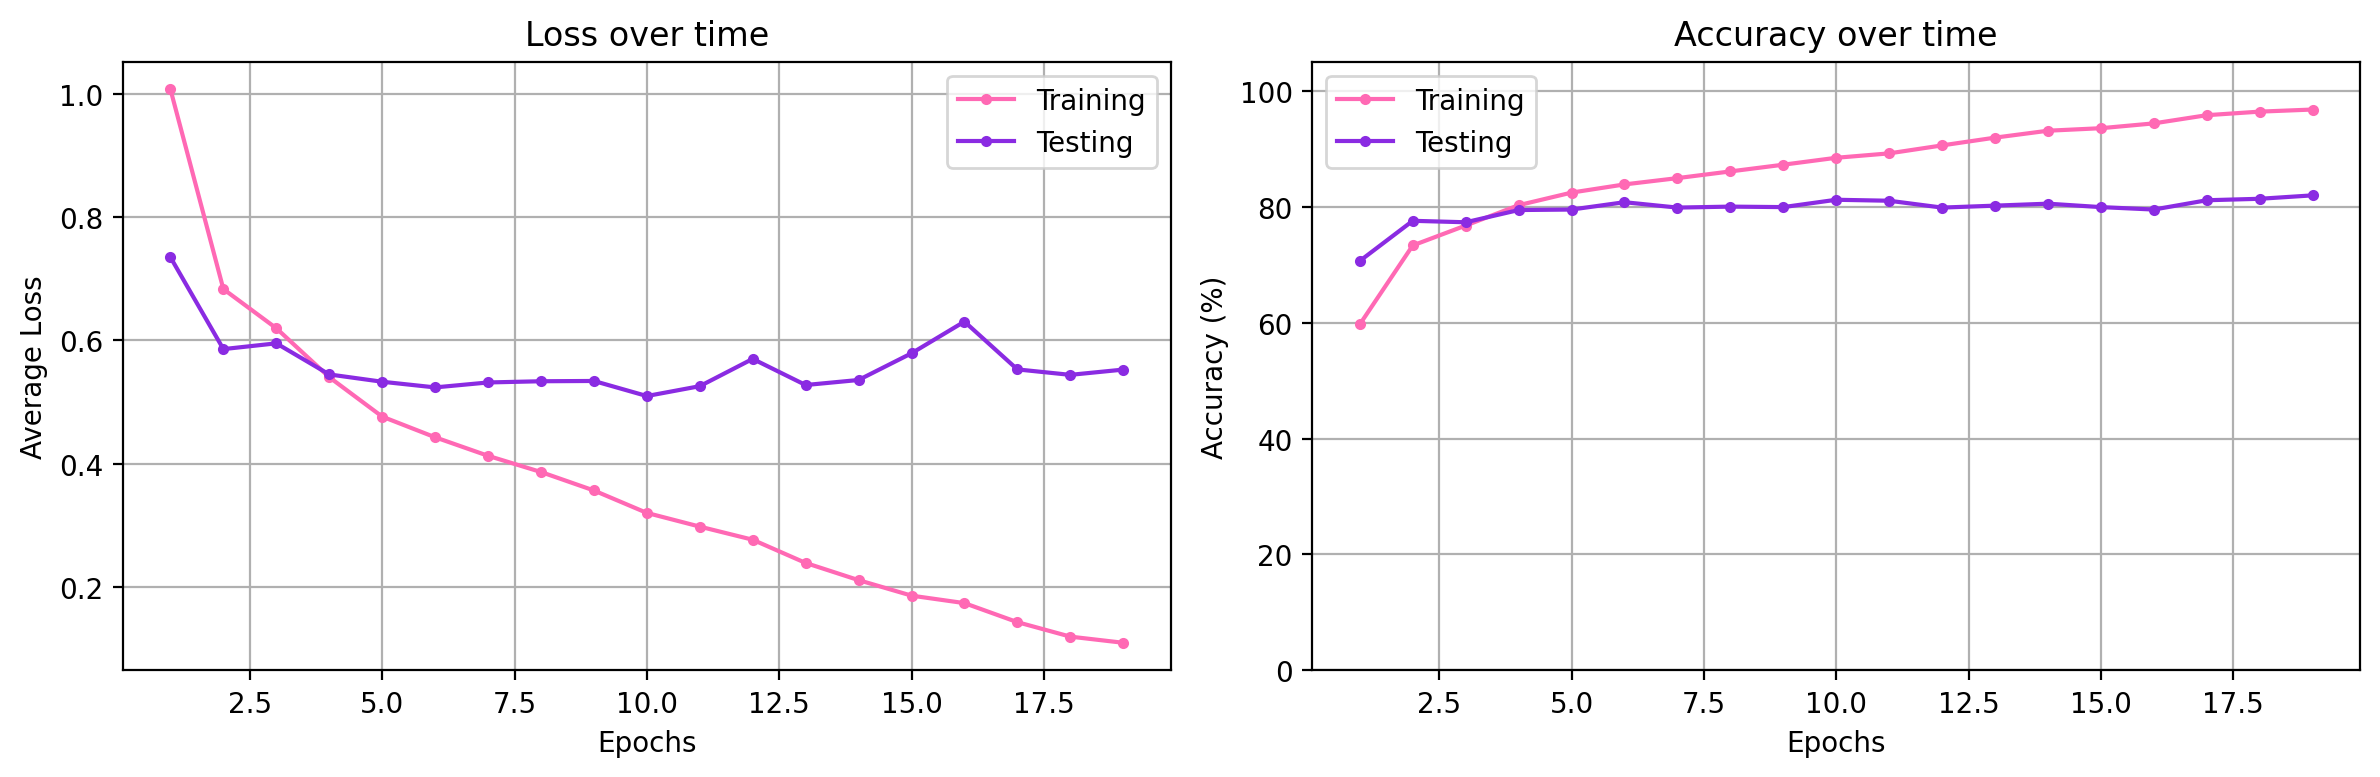

In [12]:
# Training loop
steps = len(train_loader)
loss_train, loss_test = [], []
accuracy_train, accuracy_test = [], []
fig = plt.figure(figsize=(12, 4))

for epoch in tqdm(range(EPOCHS)):

    # Training phase
    model.train()
    correct_train = 0
    total_train = 0
    epoch_train_loss = 0.0

    for waveform, labels in train_loader:

        # Move tensors to the configured device
        waveform = waveform.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(waveform)
        loss = criterion(outputs, labels)
        epoch_train_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()

    # Average training loss for this epoch
    avg_train_loss = epoch_train_loss / len(train_loader)
    loss_train.append(avg_train_loss)
    accuracy_train.append(100 * correct_train / total_train)

    # Testing phase
    model.eval()
    correct_test = 0
    total_test = 0
    epoch_test_loss = 0.0

    with torch.no_grad():

        for waveform, labels in test_loader:

            # Move tensors to the configured device
            waveform = waveform.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(waveform)
            loss = criterion(outputs, labels)
            epoch_test_loss += loss.item()

            # Calculate test accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    # Average test loss for this epoch
    avg_test_loss = epoch_test_loss / len(test_loader)
    loss_test.append(avg_test_loss)
    accuracy_test.append(100 * correct_test / total_test)

    # Update learning rate based on test loss
    scheduler.step(avg_test_loss)

    # Early stopping check
    if avg_test_loss < best_test_loss:
        best_test_loss = avg_test_loss
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), "models/cnn1d_best.ckpt")
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        print(f"Best test loss: {best_test_loss:.4f}")
        break

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}, "
            f"Train Acc: {accuracy_train[-1]:.2f}%, Test Acc: {accuracy_test[-1]:.2f}%"
        )

    # Plot loss and accuracy
    fig.clf()

    # Plot loss
    ax1 = plt.subplot(1, 2, 1)
    epochs = np.arange(1, epoch + 2)
    ax1.plot(
        epochs,
        loss_train,
        label="Training",
        color="hotpink",
        marker="o",
        markersize=3,
    )
    ax1.plot(
        epochs,
        loss_test,
        label="Testing",
        color="blueviolet",
        marker="o",
        markersize=3,
    )
    ax1.legend()
    ax1.grid()
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Average Loss")
    ax1.set_title("Loss over time")

    # Plot accuracy
    ax2 = plt.subplot(1, 2, 2)
    epochs_acc = np.arange(1, epoch + 2)
    ax2.plot(
        epochs_acc,
        accuracy_train,
        label="Training",
        color="hotpink",
        marker="o",
        markersize=3,
    )
    ax2.plot(
        epochs_acc,
        accuracy_test,
        label="Testing",
        color="blueviolet",
        marker="o",
        markersize=3,
    )
    ax2.legend()
    ax2.grid()
    ax2.set_xlabel("Epochs")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Accuracy over time")
    ax2.set_ylim([0, 105])

    plt.tight_layout()
    fig.savefig("loss_accuracy_cnn1d.png", bbox_inches="tight", dpi=100)

print(f"\nFinal Training Accuracy: {accuracy_train[-1]:.2f}%")
print(f"Final Test Accuracy: {accuracy_test[-1]:.2f}%")

Classification Report:
              precision    recall  f1-score   support

          AV       0.84      0.75      0.79       214
          IC       0.81      0.83      0.82       257
          LP       0.82      0.86      0.84       247
          TR       0.90      0.90      0.90       241
          VT       0.73      0.74      0.74       226

    accuracy                           0.82      1185
   macro avg       0.82      0.82      0.82      1185
weighted avg       0.82      0.82      0.82      1185



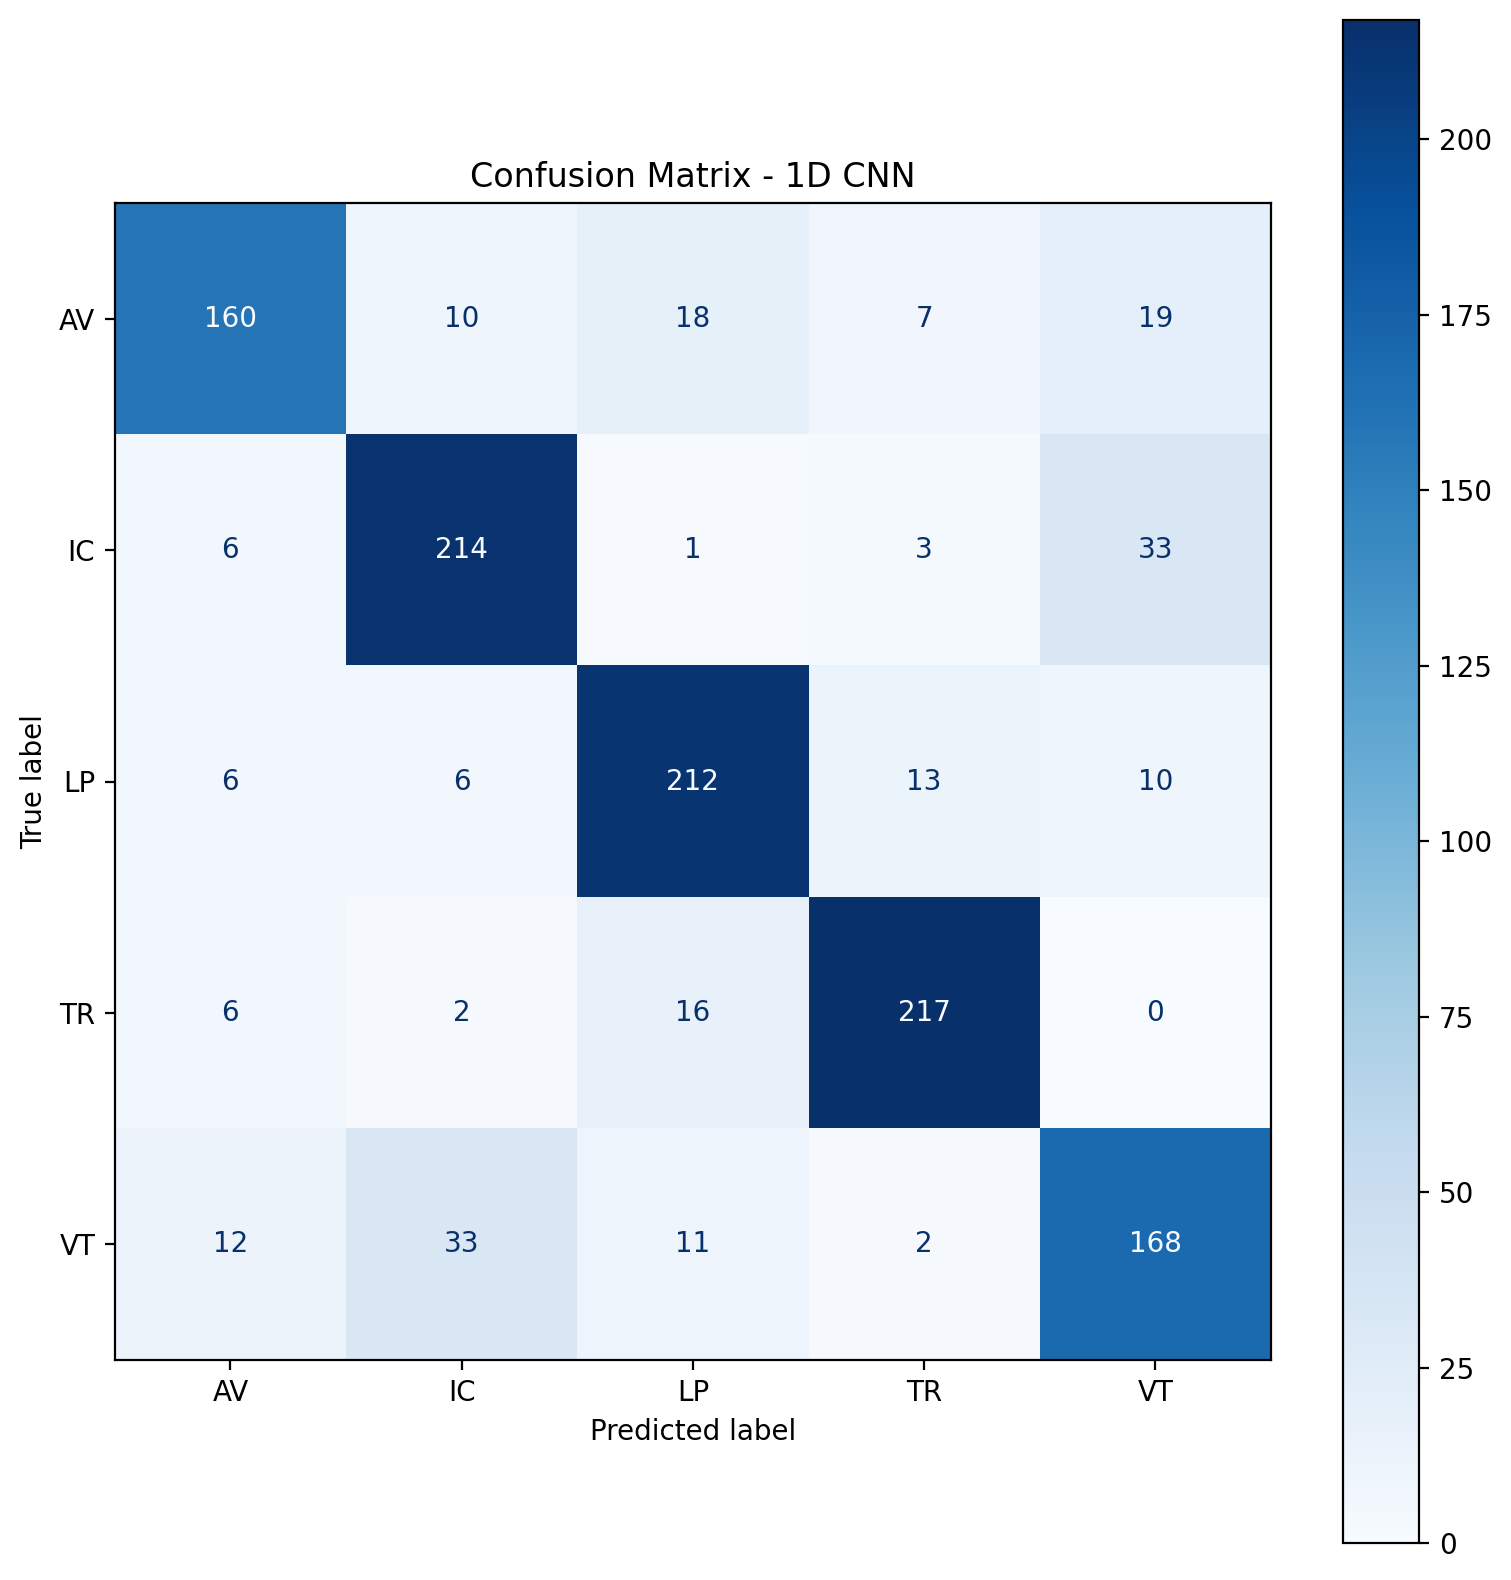

In [13]:
# Evaluate the model
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for waveform, labels in test_loader:
        waveform = waveform.to(device)
        labels = labels.to(device)

        outputs = model(waveform)
        _, predicted = torch.max(outputs.data, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Print classification report
print("Classification Report:")
print(
    classification_report(all_labels, all_predictions, target_names=y_uniques)
)

# Plot confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y_uniques)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - 1D CNN")
plt.tight_layout()
plt.savefig("confusion_matrix_cnn1d.png", bbox_inches="tight", dpi=100)
plt.show()

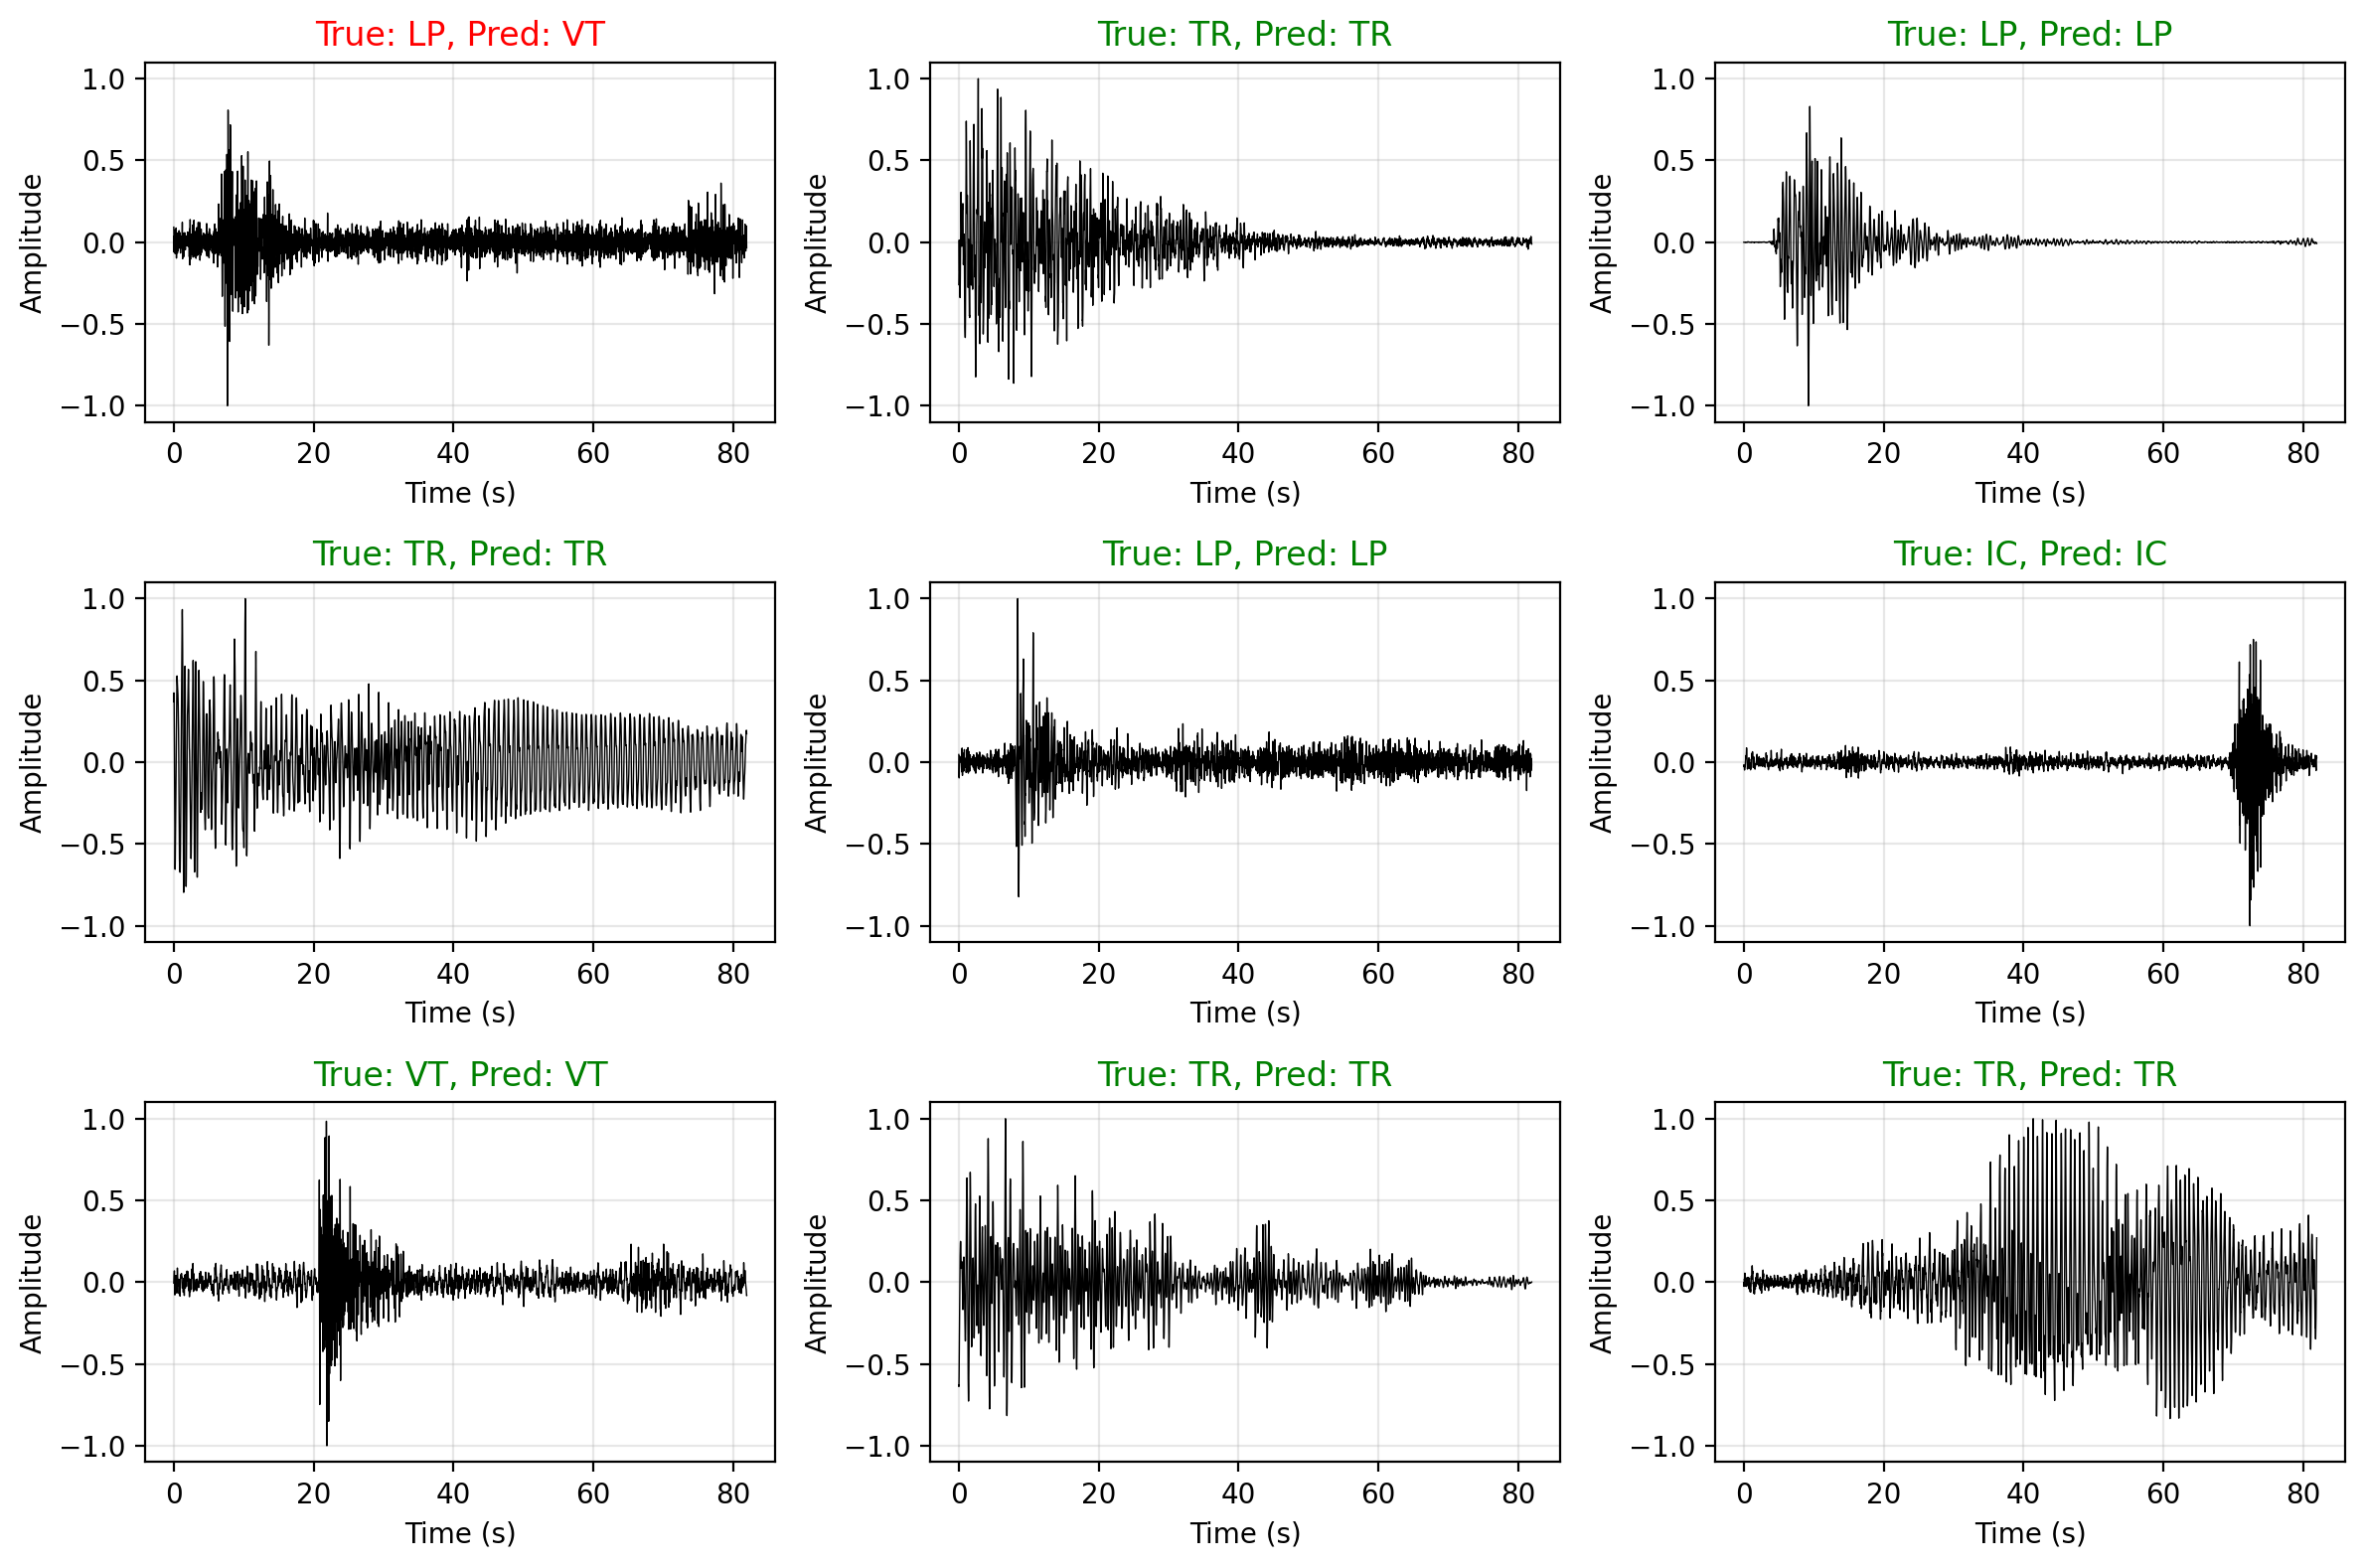

In [14]:
# Visualize some predictions
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.ravel()

# Get random test samples
indices = np.random.choice(len(X_test), 9, replace=False)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        waveform = torch.tensor(X_test[idx : idx + 1].astype(np.float32)).to(
            device
        )
        output = model(waveform)
        _, predicted = torch.max(output.data, 1)

        # Plot waveform
        time = np.arange(len(X_test[idx])) / sampling_rate
        axes[i].plot(time, X_test[idx], "k-", lw=0.5)

        # Set title with prediction
        true_label = y_uniques[y_test[idx]]
        pred_label = y_uniques[predicted.cpu().numpy()[0]]
        color = "green" if true_label == pred_label else "red"
        axes[i].set_title(
            f"True: {true_label}, Pred: {pred_label}", color=color
        )
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(alpha=0.3)
        axes[i].set_ylim([-1.1, 1.1])

plt.tight_layout()
plt.savefig("predictions_cnn1d.png", bbox_inches="tight", dpi=100)
plt.show()

In [15]:
# Save the model
model_path = "models/cnn1d.ckpt"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to models/cnn1d.ckpt
